# 01 — EDA (Phase 1)

Distributions and sanity checks on the ingested metro. Run `python -m rrs.ingest` first to build `data/yelp.duckdb`. Query logic lives in `rrs.eda`; this notebook just displays it.

In [1]:
import sys; sys.path.insert(0, '../src')
import matplotlib.pyplot as plt
from rrs import eda

con = eda.connect()
label = eda.metro_label(con)
print('Metro:', label)

Metro: Philadelphia


## Overview & geography

In [2]:
eda.overview(con)

,table,rows
0,businesses,44840
1,reviews,1930159
2,users,513947
3,tips,235828
4,checkins,38781


In [3]:
eda.geo_breakdown(con)

,state,businesses,yelp_review_count
0,PA,34039,1540790.0
1,NJ,8536,249837.0
2,DE,2265,67370.0


In [4]:
eda.top_cities(con)

,city,state,businesses
0,Philadelphia,PA,14567
1,Wilmington,DE,1445
2,Cherry Hill,NJ,959
3,West Chester,PA,838
4,King of Prussia,PA,560
5,Doylestown,PA,539
6,Bensalem,PA,454
7,Norristown,PA,448
8,Exton,PA,419
9,Marlton,NJ,415


In [5]:
eda.review_date_range(con)

,first_review,last_review,n_reviews
0,2005-02-16 04:06:26,2022-01-19 19:48:45,1930159


## Reviews per user / per business

In [6]:
eda.reviews_per_user(con)

,n_users,min,p50,p90,p99,max,mean,one_review_users
0,513954,1,1.0,7.0,39.0,3046,3.755509,290208.0


In [7]:
eda.reviews_per_business(con)

,n_businesses,min,p50,p90,p99,max,mean
0,44840,5,15.0,95.0,435.61,5778,43.045473


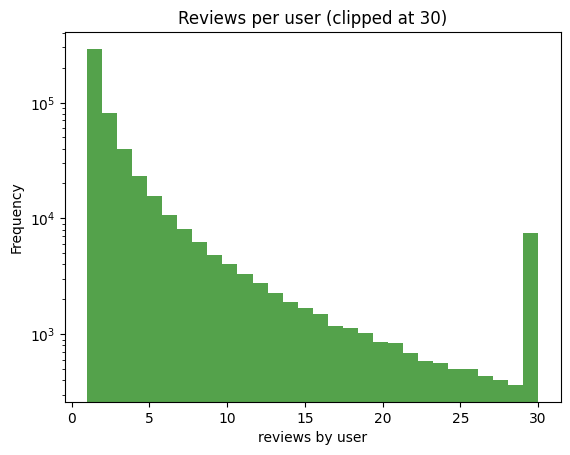

In [8]:
rpu = con.execute('SELECT count(*) AS n FROM reviews GROUP BY user_id').df()
ax = rpu['n'].clip(upper=30).plot.hist(bins=30, logy=True, color='#54A24B')
ax.set(title='Reviews per user (clipped at 30)', xlabel='reviews by user'); plt.show()

## Ratings & temporal patterns

In [9]:
eda.rating_distribution(con)

,stars,n,pct
0,1.0,306710,15.9
1,2.0,163638,8.5
2,3.0,208328,10.8
3,4.0,427541,22.2
4,5.0,823942,42.7


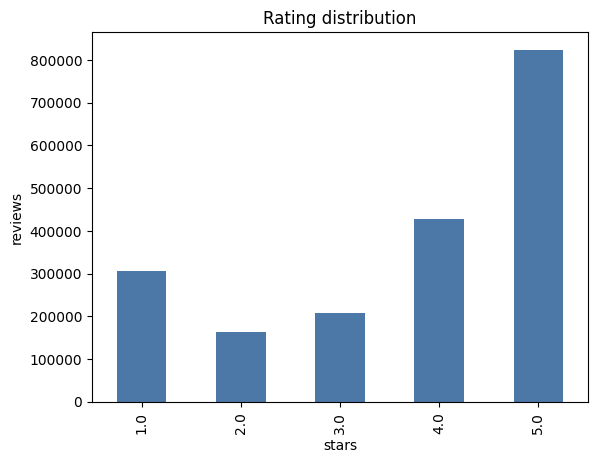

In [10]:
r = eda.rating_distribution(con)
ax = r.plot.bar(x='stars', y='n', legend=False, color='#4C78A8')
ax.set(title='Rating distribution', ylabel='reviews'); plt.show()

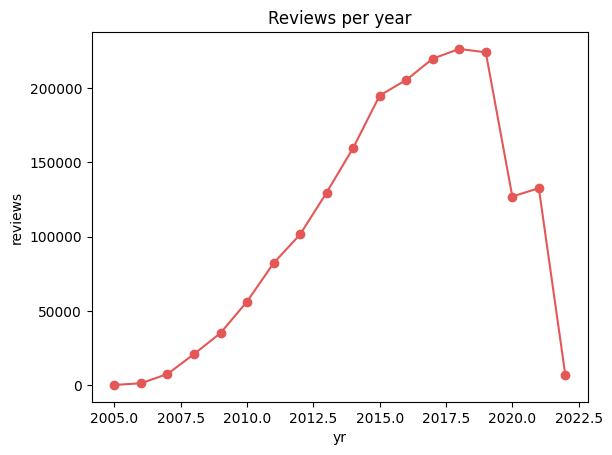

In [11]:
y = eda.reviews_per_year(con)
ax = y.plot(x='yr', y='n', marker='o', legend=False, color='#E45756')
ax.set(title='Reviews per year', ylabel='reviews'); plt.show()

## Review length & account quality

In [12]:
eda.review_length(con)

,min,p50,p90,p99,max,mean
0,1,429.0,1217.0,2680.0,5000,590.297677


In [13]:
eda.account_age_vs_reviews(con)

,account_age,n_users,avg_lifetime_reviews,median_lifetime_reviews
0,0 <30d,999,1.514515,1.0
1,1 30-180d,3680,1.949457,1.0
2,2 180-365d,5013,3.227010,1.0
3,3 1-3y,34657,4.859711,2.0
4,4 >3y,469598,29.514344,5.0
